In [1]:
import pandas as pd
import numpy as np
import os
import sys
notebook_dir = os.path.abspath(os.path.dirname(''))
project_root = os.path.dirname(notebook_dir)
sys.path.append(project_root)
import pandas as pd
from src.utils.db_utils import get_connection, execute_query


from src.features import team_level_features_class
from src.models import model
from src.utils.y_variable import build_spread_variable

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

In [2]:
nfl_model=model.NFLPredictor()
nfl_model.build_x_y_variable()

Successfully connected to the database!
Successfully connected to the database!


In [3]:
model_parameters={"n_estimators": [500,1000, 1500,2000],
                     "max_depth": [1,3,5,10],
                     "min_samples_leaf": [.01,.05,.1]}
nfl_model.build_random_forest_model(model_parameters)

In [ ]:
nfl_model.model_prediction(nfl_model.rf_model, True, True)

In [9]:
predictions=nfl_model.rf_model.predict(nfl_model.x_test)

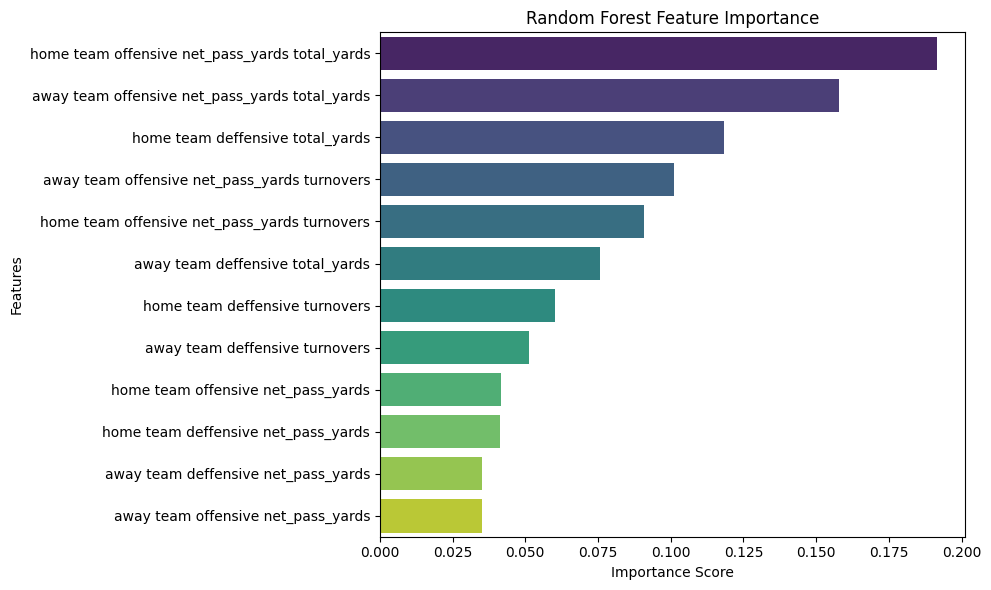

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
feature_importance = pd.DataFrame({
    'feature': nfl_model.x_y.iloc[:,:-1].columns,
    'importance': nfl_model.rf_model.feature_importances_
}).sort_values('importance', ascending=False)


# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', 
            palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

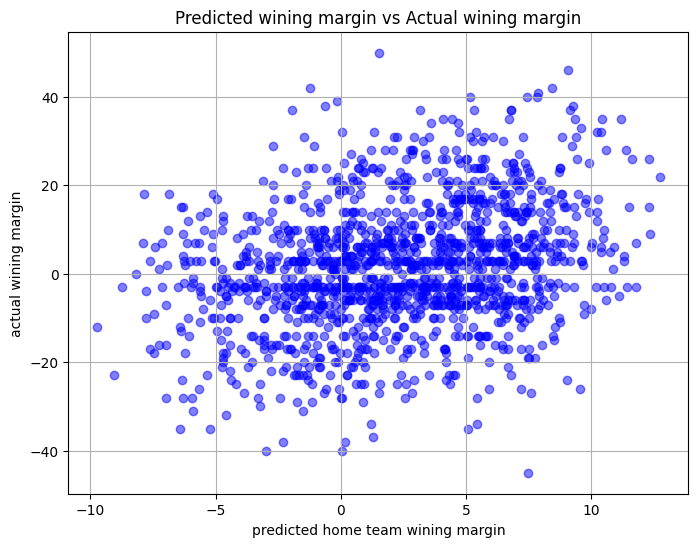

In [10]:
plt.figure(figsize=(8, 6))  # Set figure size
plt.scatter(predictions, nfl_model.y_test, color='blue', alpha=0.5)  # Create scatter plot

# Add labels and title
plt.xlabel('predicted home team wining margin')
plt.ylabel('actual wining margin')
plt.title('Predicted wining margin vs Actual wining margin')

# Display the plot
plt.grid(True)  # Add grid
plt.show()